#### Dataset

In [4]:
# fruits.zip
# https://mitu.co.in/dataset 

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model
from keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Create the image data generator objects

In [12]:
train_datagen = ImageDataGenerator(rescale=1/255, zoom_range=0.2,
                                  horizontal_flip=True, vertical_flip=True)

test_datagen = ImageDataGenerator(rescale=1/255)

#### Read the images

In [13]:
train = train_datagen.flow_from_directory(
    'datasets/fruits/dataset/training_set/', 
    class_mode='binary', 
    target_size=(64,64)
)

Found 13 images belonging to 2 classes.


In [14]:
train.filenames

['apple/1.jpg',
 'apple/2.jpeg',
 'apple/3.jpeg',
 'apple/4.jpeg',
 'apple/5.jpg',
 'apple/6.jpg',
 'apple/7.jpg',
 'orange/1.jpeg',
 'orange/2.jpg',
 'orange/3.jpeg',
 'orange/4.jpeg',
 'orange/5.jpg',
 'orange/6.jpg']

In [15]:
train.class_indices

{'apple': 0, 'orange': 1}

In [16]:
test= test_datagen.flow_from_directory(
    'datasets/fruits/dataset/test_set/', 
    class_mode='binary', 
    target_size=(64,64)
)

Found 6 images belonging to 2 classes.


In [17]:
test.class_indices

{'apple': 0, 'orange': 1}

#### Build the model

In [22]:
model = Sequential()

model.add(Input(shape=(64,64,3)))

model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [23]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,849 (202.54 KB)

 Trainable params: 51,849 (202.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy'])

In [26]:
model.fit(train, validation_data=test, epochs=10, batch_size=1) 

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9231 - loss: 0.4714 - val_accuracy: 0.8333 - val_loss: 0.4828
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7692 - loss: 0.4891 - val_accuracy: 1.0000 - val_loss: 0.4552
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8462 - loss: 0.4550 - val_accuracy: 1.0000 - val_loss: 0.4342
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8462 - loss: 0.4411 - val_accuracy: 1.0000 - val_loss: 0.4202
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7692 - loss: 0.4165 - val_accuracy: 1.0000 - val_loss: 0.3871
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7692 - loss: 0.4238 - val_accuracy: 1.0000 - val_loss: 0.3416
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8462 - loss: 0.3443 - val_accuracy: 1.0000 - val_loss: 0.3110
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8462 - loss: 0.3858 - val_accuracy: 1.0000 - val_loss:

#### Prediction on new images

In [28]:
import cv2

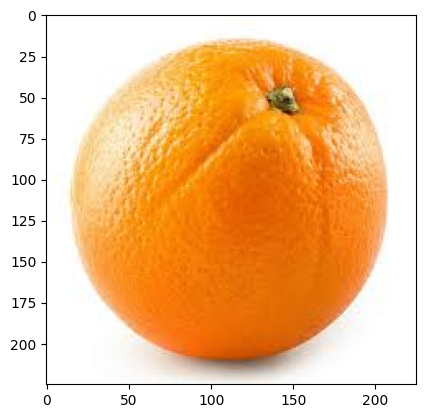

In [30]:
new1 = plt.imread('datasets/fruits/dataset/sample1.jpg')
plt.imshow(new1)

In [34]:
new1 = plt.imread('datasets/fruits/dataset/sample1.jpg')
new1 = cv2.resize(new1, (64, 64))
new1 = new1.reshape(1,64,64,3)
result = model.predict(new1, verbose=False)
if result[0][0] == 1:
    print('Orange')
else:
    print("Apple")

Orange


In [35]:
new1 = plt.imread('datasets/fruits/dataset/sample2.jpg')
new1 = cv2.resize(new1, (64, 64))
new1 = new1.reshape(1,64,64,3)
result = model.predict(new1, verbose=False)
if result[0][0] == 1:
    print('Orange')
else:
    print("Apple")

Apple
